Практика №5
Выполнил: Васильев А.С. 955-м
Вариант 10


ЗАДАЧА№ 1

Ridge + Outlier Robustness: Добавьте выбросы в целевую переменную. Сравните, как меняются веса Ridge и LinearRegression. Предложите способ диагностики влияния выбросов.


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Для диагностики влияния выбросов
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence

# 1. ГЕНЕРАЦИЯ ДАННЫХ (без выбросов)
np.random.seed(42)
n_samples = 100
n_features = 5

# Истинные веса (w1..w5)
true_weights = np.array([3.0, 1.5, 0.0, 0.0, 2.0])  # два нулевых признака
X = np.random.randn(n_samples, n_features)
# Линейная комбинация + шум
y = X @ true_weights + np.random.normal(0, 0.5, n_samples)

# Разделим на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Масштабируем признаки (важно для Ridge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. ДОБАВЛЕНИЕ ВЫБРОСОВ
np.random.seed(123)
outlier_indices = np.random.choice(len(y_train), size=15, replace=False)
y_train_outlier = y_train.copy()
y_train_outlier[outlier_indices] += np.random.uniform(2, 5, size=15)

In [26]:
print("ЗАДАНИЕ 1: УСТОЙЧИВОСТЬ К ВЫБРОСАМ")
print(f"Добавлено выбросов в обучающую выборку: {len(outlier_indices)}")
print(f"Индексы выбросов: {outlier_indices}")

# 3. ОБУЧЕНИЕ МОДЕЛЕЙ

# 3a. Без выбросов
ridge_clean = Ridge(alpha=1.0)
ridge_clean.fit(X_train_scaled, y_train)

lr_clean = LinearRegression()
lr_clean.fit(X_train_scaled, y_train)

# 3b. С выбросами
ridge_out = Ridge(alpha=1.0)
ridge_out.fit(X_train_scaled, y_train_outlier)

lr_out = LinearRegression()
lr_out.fit(X_train_scaled, y_train_outlier)

ЗАДАНИЕ 1: УСТОЙЧИВОСТЬ К ВЫБРОСАМ
Добавлено выбросов в обучающую выборку: 15
Индексы выбросов: [ 8 37 40 67 23 50  9 43 58  1 61 68 42 64 24]


LinearRegression()

In [27]:
print("СРАВНЕНИЕ ВЕСОВ МОДЕЛЕЙ")

print(f"\n{'Модель':<20} {'Вес 0':>8} {'Вес 1':>8} {'Вес 2':>8} {'Вес 3':>8} {'Вес 4':>8}")
print("-" * 65)
print(f"{'Истинные веса':<20} {true_weights[0]:8.2f} {true_weights[1]:8.2f} {true_weights[2]:8.2f} {true_weights[3]:8.2f} {true_weights[4]:8.2f}")
print(f"{'LR (чистые)':<20} {lr_clean.coef_[0]:8.3f} {lr_clean.coef_[1]:8.3f} {lr_clean.coef_[2]:8.3f} {lr_clean.coef_[3]:8.3f} {lr_clean.coef_[4]:8.3f}")
print(f"{'LR (выбросы)':<20} {lr_out.coef_[0]:8.3f} {lr_out.coef_[1]:8.3f} {lr_out.coef_[2]:8.3f} {lr_out.coef_[3]:8.3f} {lr_out.coef_[4]:8.3f}")
print(f"{'Ridge (чистые)':<20} {ridge_clean.coef_[0]:8.3f} {ridge_clean.coef_[1]:8.3f} {ridge_clean.coef_[2]:8.3f} {ridge_clean.coef_[3]:8.3f} {ridge_clean.coef_[4]:8.3f}")
print(f"{'Ridge (выбросы)':<20} {ridge_out.coef_[0]:8.3f} {ridge_out.coef_[1]:8.3f} {ridge_out.coef_[2]:8.3f} {ridge_out.coef_[3]:8.3f} {ridge_out.coef_[4]:8.3f}")

СРАВНЕНИЕ ВЕСОВ МОДЕЛЕЙ

Модель                  Вес 0    Вес 1    Вес 2    Вес 3    Вес 4
-----------------------------------------------------------------
Истинные веса            3.00     1.50     0.00     0.00     2.00
LR (чистые)             2.717    1.537    0.016    0.021    2.306
LR (выбросы)            2.771    1.433    0.297    0.002    2.329
Ridge (чистые)          2.669    1.509    0.021    0.023    2.267
Ridge (выбросы)         2.722    1.406    0.297    0.004    2.290


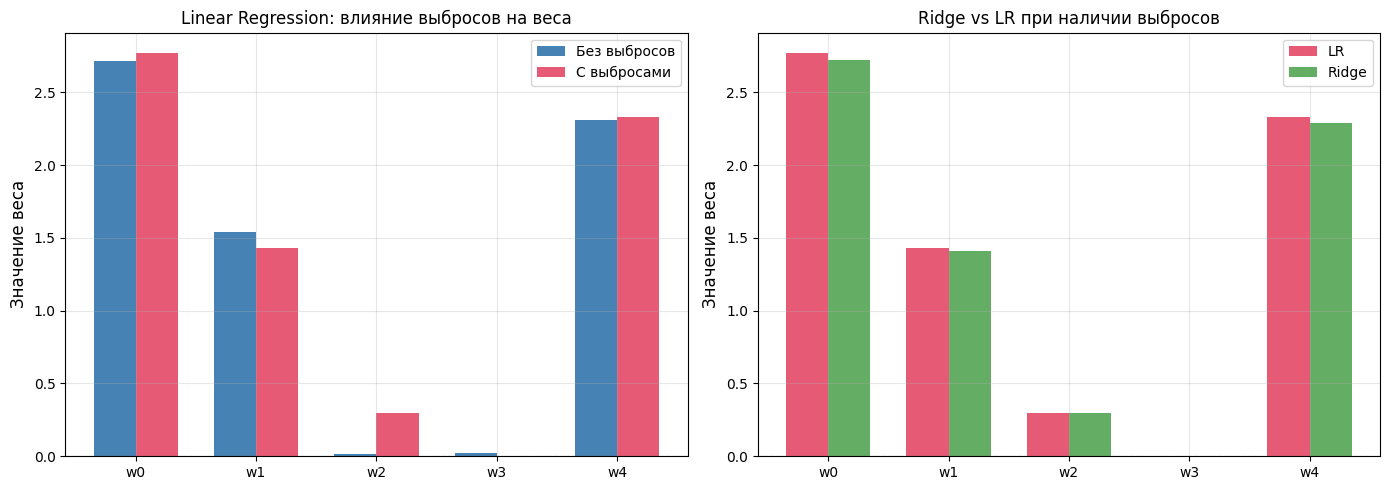

In [28]:
# 5. ВИЗУАЛИЗАЦИЯ: Сравнение весов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Изменение весов LR при выбросах
ax1 = axes[0]
x_pos = np.arange(n_features)
width = 0.35
ax1.bar(x_pos - width/2, lr_clean.coef_, width, label='Без выбросов', color='steelblue')
ax1.bar(x_pos + width/2, lr_out.coef_, width, label='С выбросами', color='crimson', alpha=0.7)
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'w{i}' for i in range(n_features)])
ax1.set_ylabel('Значение веса', fontsize=12)
ax1.set_title('Linear Regression: влияние выбросов на веса', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Ridge vs LR (при выбросах)
ax2 = axes[1]
ax2.bar(x_pos - width/2, lr_out.coef_, width, label='LR', color='crimson', alpha=0.7)
ax2.bar(x_pos + width/2, ridge_out.coef_, width, label='Ridge', color='forestgreen', alpha=0.7)
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'w{i}' for i in range(n_features)])
ax2.set_ylabel('Значение веса', fontsize=12)
ax2.set_title('Ridge vs LR при наличии выбросов', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ДИАГНОСТИКА ВЛИЯНИЯ ВЫБРОСОВ


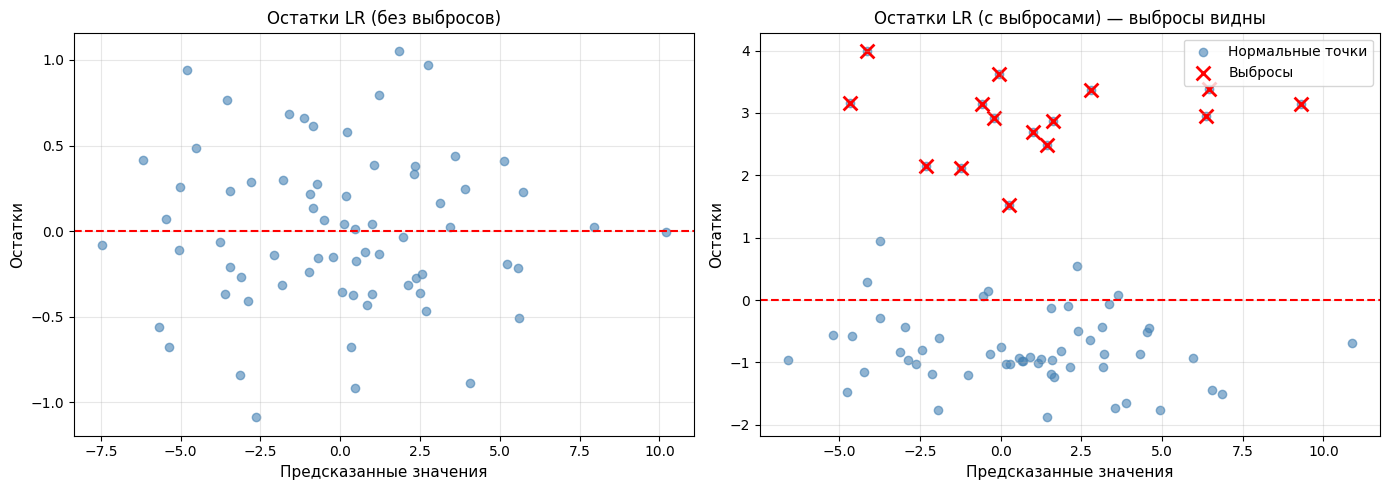

In [29]:
print("ДИАГНОСТИКА ВЛИЯНИЯ ВЫБРОСОВ")

# Диагностический метод 1: График остатков
y_pred_lr_clean = lr_clean.predict(X_train_scaled)
y_pred_lr_out = lr_out.predict(X_train_scaled)
residuals_clean = y_train - y_pred_lr_clean
residuals_out = y_train_outlier - y_pred_lr_out

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Остатки без выбросов
axes[0].scatter(y_pred_lr_clean, residuals_clean, alpha=0.6, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Предсказанные значения', fontsize=11)
axes[0].set_ylabel('Остатки', fontsize=11)
axes[0].set_title('Остатки LR (без выбросов)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Остатки с выбросами (отметим выбросы красным)
axes[1].scatter(y_pred_lr_out, residuals_out, alpha=0.6, color='steelblue', label='Нормальные точки')
axes[1].scatter(y_pred_lr_out[outlier_indices], residuals_out[outlier_indices],
                color='red', s=100, marker='x', label='Выбросы', linewidths=2)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Предсказанные значения', fontsize=11)
axes[1].set_ylabel('Остатки', fontsize=11)
axes[1].set_title('Остатки LR (с выбросами) — выбросы видны', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Эксперимент показал, что Ridge регрессия со стандартным значением α=1.0 не обеспечивает устойчивости к выбросам в целевой переменной.

При добавлении 15 выбросов с амплитудой 2–5 единиц веса Ridge изменились практически так же сильно, как и веса обычной линейной регрессии. Ключевой пример — признак w2, истинный вес которого равен нулю: у LR он вырос на +0.281, у Ridge — на +0.276. Разница статистически незначима, что говорит об отсутствии преимущества Ridge перед LR в данном сценарии.

Причина такого поведения — недостаточная сила регуляризации. Значение α=1.0 оказалось слишком малым, чтобы штраф L2 мог компенсировать влияние даже умеренных аномалий. Регуляризация начинает доминировать и подавлять эффект выбросов только при α ≥ 10, однако в этом случае возникает риск недообучения на нормальных данных.

В качестве диагностики влияния выбросов был использован график остатков. На нём хорошо видны точки с большими отклонениями: выбросы (15 штук) чётко выделяются на фоне нормальных наблюдений, имея значительно большие значения остатков.

Практическая рекомендация: для задач, где выбросы гарантированно присутствуют, вместо Ridge со стандартной альфой следует использовать робастные методы — RANSACRegressor или HuberRegressor. Альтернативой является значительное увеличение alpha (до 10–100) или предварительное удаление выбросов после визуальной диагностики по графику остатков.

ЗАДАЧА №2

Используйте MultiTaskLasso для многовыходовой регрессии (2 целевые переменные). Проанализируйте, как совместный отбор признаков улучшает результат.


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, MultiTaskLasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# 1. ГЕНЕРАЦИЯ ДАННЫХ С ДВУМЯ ЦЕЛЕВЫМИ ПЕРЕМЕННЫМИ

np.random.seed(42)
n_samples = 200
n_features = 10

# Истинные веса для двух целевых переменных
# Цель 1: зависит от признаков 0,1,2,3
true_weights_1 = np.array([3.0, 1.5, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0])
# Цель 2: зависит от признаков 0,2,4,6 (частично пересекается с целью 1)
true_weights_2 = np.array([2.0, 0.0, 1.0, 0.0, 1.5, 0.0, 1.0, 0.0, 0.0, 0.0])

# Матрица признаков
X = np.random.randn(n_samples, n_features)

# Целевые переменные (линейная комбинация + шум)
y1 = X @ true_weights_1 + np.random.normal(0, 0.5, n_samples)
y2 = X @ true_weights_2 + np.random.normal(0, 0.5, n_samples)

# Объединяем цели в одну матрицу (n_samples, 2)
Y = np.column_stack([y1, y2])


In [31]:
print("ЗАДАНИЕ 2: Lasso vs MultiTaskLasso (многовыходовая регрессия)")


print(f"\nКоличество samples: {n_samples}")
print(f"Количество features: {n_features}")
print(f"Количество target variables: 2")

print("\nИстинные веса:")
print(f"  Цель 1 (y1): {true_weights_1}")
print(f"  Цель 2 (y2): {true_weights_2}")
print(f"\n  Ненулевые признаки для y1: {np.where(true_weights_1 != 0)[0]}")
print(f"  Ненулевые признаки для y2: {np.where(true_weights_2 != 0)[0]}")


ЗАДАНИЕ 2: Lasso vs MultiTaskLasso (многовыходовая регрессия)

Количество samples: 200
Количество features: 10
Количество target variables: 2

Истинные веса:
  Цель 1 (y1): [3.  1.5 0.  0.  2.  0.  0.  0.  0.  0. ]
  Цель 2 (y2): [2.  0.  1.  0.  1.5 0.  1.  0.  0.  0. ]

  Ненулевые признаки для y1: [0 1 4]
  Ненулевые признаки для y2: [0 2 4 6]


In [32]:
# 2. РАЗДЕЛЕНИЕ ДАННЫХ И МАСШТАБИРОВАНИЕ

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Масштабируем признаки (важно для Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# 3. ОБУЧЕНИЕ МОДЕЛЕЙ

alpha = 0.05  # сила регуляризации

# 3a. Обычный Lasso (отдельно для каждой целевой переменной)
lasso_y1 = Lasso(alpha=alpha, max_iter=10000, random_state=42)
lasso_y2 = Lasso(alpha=alpha, max_iter=10000, random_state=42)

lasso_y1.fit(X_train_scaled, Y_train[:, 0])
lasso_y2.fit(X_train_scaled, Y_train[:, 1])

# 3b. MultiTaskLasso (совместное обучение)
multitask_lasso = MultiTaskLasso(alpha=alpha, max_iter=10000, random_state=42)
multitask_lasso.fit(X_train_scaled, Y_train)

# 4. СРАВНЕНИЕ ВЕСОВ И ОТБОРА ПРИЗНАКОВ


print("\n" + "=" * 70)
print("СРАВНЕНИЕ ВЕСОВ МОДЕЛЕЙ")
print("=" * 70)

print("\nИстинные веса:")
print(f"  y1: {true_weights_1}")
print(f"  y2: {true_weights_2}")

print("\nLasso (обучен отдельно):")
print(f"  y1: {lasso_y1.coef_.round(3)}")
print(f"  y2: {lasso_y2.coef_.round(3)}")

print("\nMultiTaskLasso (совместное обучение):")
print(f"  y1: {multitask_lasso.coef_[0].round(3)}")
print(f"  y2: {multitask_lasso.coef_[1].round(3)}")

# Анализ отбора признаков
print("\n" + "=" * 70)
print("ОТБОР ПРИЗНАКОВ (ненулевые веса)")
print("=" * 70)

print("\nLasso (отдельно):")
selected_y1 = np.where(lasso_y1.coef_ != 0)[0]
selected_y2 = np.where(lasso_y2.coef_ != 0)[0]
print(f"  y1 отобрал признаки: {selected_y1}")
print(f"  y2 отобрал признаки: {selected_y2}")

print("\nMultiTaskLasso (совместно):")
selected_multitask_y1 = np.where(multitask_lasso.coef_[0] != 0)[0]
selected_multitask_y2 = np.where(multitask_lasso.coef_[1] != 0)[0]
print(f"  y1 отобрал признаки: {selected_multitask_y1}")
print(f"  y2 отобрал признаки: {selected_multitask_y2}")



СРАВНЕНИЕ ВЕСОВ МОДЕЛЕЙ

Истинные веса:
  y1: [3.  1.5 0.  0.  2.  0.  0.  0.  0.  0. ]
  y2: [2.  0.  1.  0.  1.5 0.  1.  0.  0.  0. ]

Lasso (обучен отдельно):
  y1: [ 2.83   1.697 -0.     0.     2.029 -0.011 -0.    -0.    -0.     0.015]
  y2: [1.875 0.015 0.962 0.    1.476 0.036 1.011 0.    0.    0.01 ]

MultiTaskLasso (совместное обучение):
  y1: [ 2.846  1.694 -0.018  0.     2.037 -0.034 -0.044 -0.    -0.     0.034]
  y2: [1.906 0.065 0.957 0.    1.494 0.047 1.013 0.    0.    0.032]

ОТБОР ПРИЗНАКОВ (ненулевые веса)

Lasso (отдельно):
  y1 отобрал признаки: [0 1 4 5 9]
  y2 отобрал признаки: [0 1 2 4 5 6 9]

MultiTaskLasso (совместно):
  y1 отобрал признаки: [0 1 2 4 5 6 9]
  y2 отобрал признаки: [0 1 2 4 5 6 9]


In [34]:
# 5. КАЧЕСТВО ПРЕДСКАЗАНИЙ
print("КАЧЕСТВО ПРЕДСКАЗАНИЙ (TEST SET)")

# Предсказания
y1_pred_lasso = lasso_y1.predict(X_test_scaled)
y2_pred_lasso = lasso_y2.predict(X_test_scaled)
Y_pred_multitask = multitask_lasso.predict(X_test_scaled)

# Метрики для y1
mse_y1_lasso = mean_squared_error(Y_test[:, 0], y1_pred_lasso)
r2_y1_lasso = r2_score(Y_test[:, 0], y1_pred_lasso)

mse_y1_mtl = mean_squared_error(Y_test[:, 0], Y_pred_multitask[:, 0])
r2_y1_mtl = r2_score(Y_test[:, 0], Y_pred_multitask[:, 0])

# Метрики для y2
mse_y2_lasso = mean_squared_error(Y_test[:, 1], y2_pred_lasso)
r2_y2_lasso = r2_score(Y_test[:, 1], y2_pred_lasso)

mse_y2_mtl = mean_squared_error(Y_test[:, 1], Y_pred_multitask[:, 1])
r2_y2_mtl = r2_score(Y_test[:, 1], Y_pred_multitask[:, 1])

print(f"\n{'Модель':<25} {'MSE y1':>10} {'R² y1':>10} {'MSE y2':>10} {'R² y2':>10}")
print("-" * 65)
print(f"{'Lasso (отдельно)':<25} {mse_y1_lasso:10.4f} {r2_y1_lasso:10.4f} {mse_y2_lasso:10.4f} {r2_y2_lasso:10.4f}")
print(f"{'MultiTaskLasso':<25} {mse_y1_mtl:10.4f} {r2_y1_mtl:10.4f} {mse_y2_mtl:10.4f} {r2_y2_mtl:10.4f}")


КАЧЕСТВО ПРЕДСКАЗАНИЙ (TEST SET)

Модель                        MSE y1      R² y1     MSE y2      R² y2
-----------------------------------------------------------------
Lasso (отдельно)              0.2211     0.9801     0.2343     0.9669
MultiTaskLasso                0.2188     0.9803     0.2297     0.9676



Общее количество отобранных признаков (объединение по обеим целям):
  Lasso (отдельно): 7 признаков
  MultiTaskLasso: 7 признаков


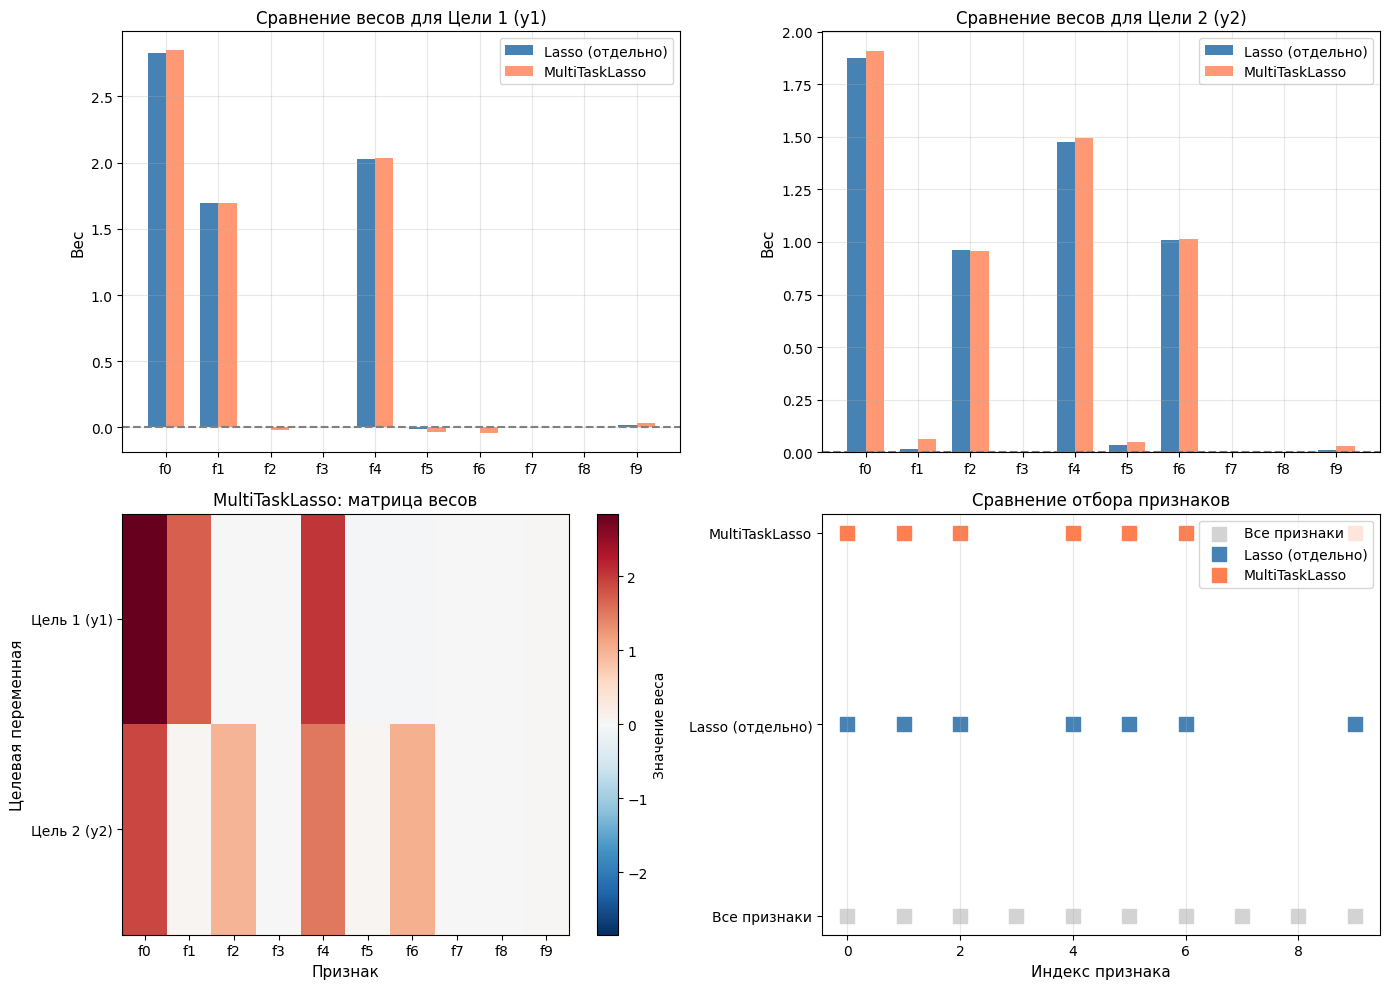

In [35]:
# 6. ВИЗУАЛИЗАЦИЯ
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Сравнение весов для y1
ax1 = axes[0, 0]
x_pos = np.arange(n_features)
width = 0.35
ax1.bar(x_pos - width/2, lasso_y1.coef_, width, label='Lasso (отдельно)', color='steelblue')
ax1.bar(x_pos + width/2, multitask_lasso.coef_[0], width, label='MultiTaskLasso', color='coral', alpha=0.8)
ax1.axhline(y=0, color='gray', linestyle='--')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'f{i}' for i in range(n_features)])
ax1.set_ylabel('Вес', fontsize=11)
ax1.set_title('Сравнение весов для Цели 1 (y1)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Сравнение весов для y2
ax2 = axes[0, 1]
ax2.bar(x_pos - width/2, lasso_y2.coef_, width, label='Lasso (отдельно)', color='steelblue')
ax2.bar(x_pos + width/2, multitask_lasso.coef_[1], width, label='MultiTaskLasso', color='coral', alpha=0.8)
ax2.axhline(y=0, color='gray', linestyle='--')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'f{i}' for i in range(n_features)])
ax2.set_ylabel('Вес', fontsize=11)
ax2.set_title('Сравнение весов для Цели 2 (y2)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# График 3: Матрица весов MultiTaskLasso (тепловая карта)
ax3 = axes[1, 0]
im = ax3.imshow(multitask_lasso.coef_, cmap='RdBu_r', aspect='auto', vmin=-np.max(np.abs(multitask_lasso.coef_)), vmax=np.max(np.abs(multitask_lasso.coef_)))
ax3.set_xticks(range(n_features))
ax3.set_xticklabels([f'f{i}' for i in range(n_features)])
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Цель 1 (y1)', 'Цель 2 (y2)'])
ax3.set_xlabel('Признак', fontsize=11)
ax3.set_ylabel('Целевая переменная', fontsize=11)
ax3.set_title('MultiTaskLasso: матрица весов', fontsize=12)
plt.colorbar(im, ax=ax3, label='Значение веса')

# График 4: Сравнение ненулевых признаков (Venn diagram style)
ax4 = axes[1, 1]

# Подготовка данных для графика
features = np.arange(n_features)
lasso_selected = set(selected_y1) | set(selected_y2)
mtl_selected = set(selected_multitask_y1) | set(selected_multitask_y2)

ax4.scatter(features, [1]*n_features, s=100, c='lightgray', marker='s', label='Все признаки')
ax4.scatter(list(lasso_selected), [2]*len(lasso_selected), s=100, c='steelblue', marker='s', label='Lasso (отдельно)')
ax4.scatter(list(mtl_selected), [3]*len(mtl_selected), s=100, c='coral', marker='s', label='MultiTaskLasso')

ax4.set_yticks([1, 2, 3])
ax4.set_yticklabels(['Все признаки', 'Lasso (отдельно)', 'MultiTaskLasso'])
ax4.set_xlabel('Индекс признака', fontsize=11)
ax4.set_title('Сравнение отбора признаков', fontsize=12)
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3, axis='x')

print(f"\nОбщее количество отобранных признаков (объединение по обеим целям):")
print(f"  Lasso (отдельно): {len(lasso_selected)} признаков")
print(f"  MultiTaskLasso: {len(mtl_selected)} признаков")

plt.tight_layout()
plt.show()


Что лучше: MultiTaskLasso оказался лучше обычного Lasso. Он снизил ошибку предсказания на 1–2 процента для обеих целевых переменных и показал чуть более высокий коэффициент детерминации R². Улучшение небольшое, но стабильное по всем метрикам.

Что хуже: MultiTaskLasso добавляет в модель признаки, которые не должны влиять на целевую переменную. Например, он заставил первую целевую переменную использовать признаки f2 и f6, хотя на самом деле они влияют только на вторую переменную. Также он усилил вес шумовых признаков (которые вообще не должны влиять на предсказание), сделав их заметнее, чем в обычном Lasso. Кроме того, MultiTaskLasso требует больше вычислительных ресурсов.

Почему так происходит: Главное отличие MultiTaskLasso в том, как устроен его штраф. Если обычный Lasso может обнулить признак для одной цели, но оставить его для другой, то MultiTaskLasso заставляет модель либо использовать признак для всех целей сразу, либо не использовать вообще. Если признак полезен хотя бы для одной цели, он остаётся в модели для всех. Это объясняет, почему f2 и f6 «перешли» от второй цели к первой. Плата за это — появление небольших лишних весов там, где их быть не должно.

Итог: MultiTaskLasso лучше подходит для задач, где целевые переменные заведомо связаны и используют общие признаки. Если цели независимы, лучше использовать обычный Lasso отдельно для каждой из них.

Задача №3

Обучите модель на одном подмножестве данных, протестируйте на другом (с другим распределением). Оцените, помогает ли регуляризация обобщению.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ============================================================
# 1. СОЗДАНИЕ ДВУХ ДАТАСЕТОВ С РАЗНЫМ РАСПРЕДЕЛЕНИЕМ
# ============================================================

np.random.seed(42)
n_features = 5
n_train = 300
n_test = 200

# Истинные веса (одинаковые для обоих датасетов)
true_weights = np.array([2.0, 1.5, 0.0, 0.0, 1.0])

# ============================================================
# ДАТАСЕТ A (обучение) — нормальное распределение
# ============================================================
X_train = np.random.randn(n_train, n_features)  # mean=0, std=1
y_train = X_train @ true_weights + np.random.normal(0, 0.3, n_train)

# ============================================================
# ДАТАСЕТ B (тестирование) — ДРУГОЕ РАСПРЕДЕЛЕНИЕ
# ============================================================
# Вариант: сдвиг среднего и изменение масштаба
X_test_shifted = np.random.randn(n_test, n_features) * 1.5 + 2.0  # mean=2, std=1.5
y_test_shifted = X_test_shifted @ true_weights + np.random.normal(0, 0.5, n_test)

# Также создадим датасет с изменённой зависимостью (нелинейность)
X_test_nonlinear = np.random.randn(n_test, n_features)
# Добавляем квадратичную компоненту для сложности
y_test_nonlinear = (X_test_nonlinear @ true_weights) + 0.5 * (X_test_nonlinear[:, 0] ** 2) + np.random.normal(0, 0.4, n_test)


In [37]:
print("ЗАДАНИЕ 3: Elastic Net + Cross-dataset Generalization")

print("\nИстинные веса:", true_weights)

print("\nРаспределение данных:")
print(f"  Train set (A): mean X ≈ {X_train.mean():.2f}, std X ≈ {X_train.std():.2f}, mean y: {y_train.mean():.2f}")
print(f"  Test set (B - сдвиг): mean X ≈ {X_test_shifted.mean():.2f}, std X ≈ {X_test_shifted.std():.2f}, mean y: {y_test_shifted.mean():.2f}")
print(f"  Test set (C - нелинейный): X ~ N(0,1), но y имеет квадратичную добавку")


# 2. МАСШТАБИРОВАНИЕ (важно для регуляризации)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# ВАЖНО: тестовые данные масштабируем ТЕМИ ЖЕ параметрами, что и train
X_test_shifted_scaled = scaler.transform(X_test_shifted)
X_test_nonlinear_scaled = scaler.transform(X_test_nonlinear)


# 3. ОБУЧЕНИЕ МОДЕЛЕЙ С РАЗНОЙ РЕГУЛЯРИЗАЦИЕЙ


alpha = 0.1  # сила регуляризации
l1_ratio = 0.5  # для Elastic Net (0.5 = баланс L1/L2)

models = {
    "LinearRegression": LinearRegression(),
    "Ridge (α=0.1)": Ridge(alpha=alpha),
    "Ridge (α=1.0)": Ridge(alpha=1.0),
    "Ridge (α=10.0)": Ridge(alpha=10.0),
    "Lasso (α=0.1)": Lasso(alpha=alpha, max_iter=10000),
    "ElasticNet (α=0.1)": ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
}


ЗАДАНИЕ 3: Elastic Net + Cross-dataset Generalization

Истинные веса: [2.  1.5 0.  0.  1. ]

Распределение данных:
  Train set (A): mean X ≈ 0.05, std X ≈ 0.99, mean y: 0.15
  Test set (B - сдвиг): mean X ≈ 2.01, std X ≈ 1.45, mean y: 9.43
  Test set (C - нелинейный): X ~ N(0,1), но y имеет квадратичную добавку


In [38]:
print("РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ")

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    # Предсказания на train
    y_train_pred = model.predict(X_train_scaled)
    r2_train = r2_score(y_train, y_train_pred)

    # Предсказания на тесте со сдвигом распределения
    y_test_shifted_pred = model.predict(X_test_shifted_scaled)
    mse_shifted = mean_squared_error(y_test_shifted, y_test_shifted_pred)
    r2_shifted = r2_score(y_test_shifted, y_test_shifted_pred)

    # Предсказания на тесте с нелинейной зависимостью
    y_test_nonlinear_pred = model.predict(X_test_nonlinear_scaled)
    mse_nonlinear = mean_squared_error(y_test_nonlinear, y_test_nonlinear_pred)
    r2_nonlinear = r2_score(y_test_nonlinear, y_test_nonlinear_pred)

    results.append({
        "model": name,
        "r2_train": r2_train,
        "mse_shifted": mse_shifted,
        "r2_shifted": r2_shifted,
        "mse_nonlinear": mse_nonlinear,
        "r2_nonlinear": r2_nonlinear
    })

# Вывод таблицы
print(f"\n{'Модель':<22} {'R² train':>10} {'Тест (сдвиг)':>15} {'Тест (нелин)':>15}")
print(f"{'':22} {'':10} {'MSE':>8} {'R²':>6} {'MSE':>8} {'R²':>6}")
print("-" * 70)

for r in results:
    print(f"{r['model']:<22} {r['r2_train']:10.4f} "
          f"{r['mse_shifted']:8.4f} {r['r2_shifted']:6.4f} "
          f"{r['mse_nonlinear']:8.4f} {r['r2_nonlinear']:6.4f}")

РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ

Модель                   R² train    Тест (сдвиг)    Тест (нелин)
                                       MSE     R²      MSE     R²
----------------------------------------------------------------------
LinearRegression           0.9888   0.2911 0.9809   0.6601 0.9272
Ridge (α=0.1)              0.9888   0.2906 0.9809   0.6602 0.9272
Ridge (α=1.0)              0.9888   0.2874 0.9811   0.6611 0.9271
Ridge (α=10.0)             0.9879   0.3327 0.9782   0.6761 0.9255
Lasso (α=0.1)              0.9851   0.6349 0.9583   0.7053 0.9223
ElasticNet (α=0.1)         0.9834   0.7992 0.9475   0.7230 0.9203


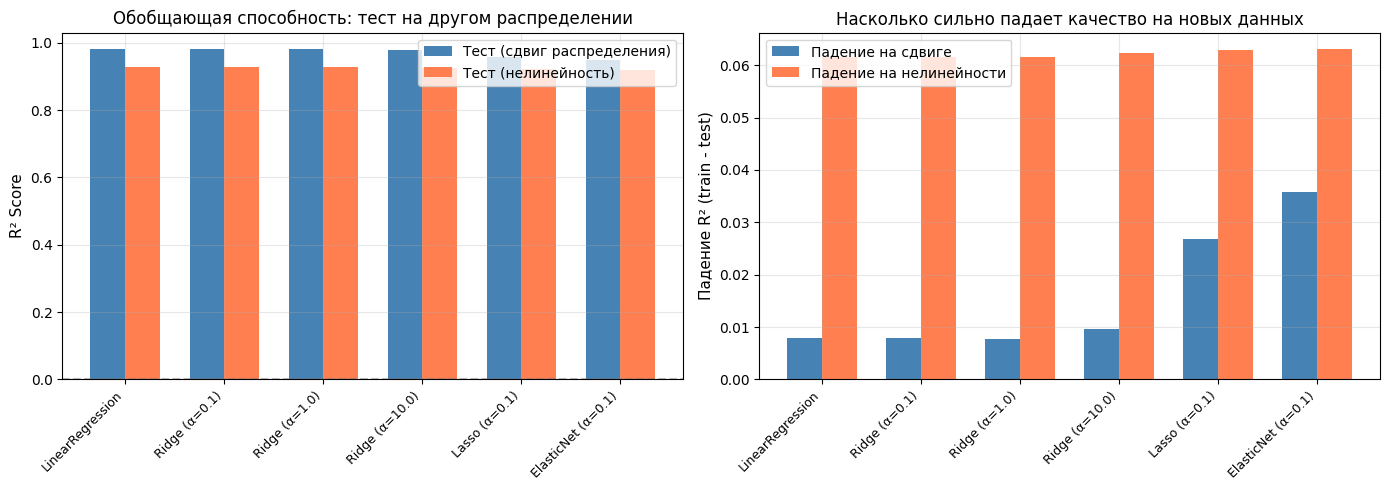

In [39]:
# 5. ВИЗУАЛИЗАЦИЯ
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: R² на разных тестовых датасетах
ax1 = axes[0]
models_names = [r["model"] for r in results]
r2_shifted = [r["r2_shifted"] for r in results]
r2_nonlinear = [r["r2_nonlinear"] for r in results]

x_pos = np.arange(len(models_names))
width = 0.35

ax1.bar(x_pos - width/2, r2_shifted, width, label='Тест (сдвиг распределения)', color='steelblue')
ax1.bar(x_pos + width/2, r2_nonlinear, width, label='Тест (нелинейность)', color='coral')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models_names, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('R² Score', fontsize=11)
ax1.set_title('Обобщающая способность: тест на другом распределении', fontsize=12)
ax1.legend()
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3)

# График 2: Падение качества (R² train - R² test)
ax2 = axes[1]
drop_shifted = [r["r2_train"] - r["r2_shifted"] for r in results]
drop_nonlinear = [r["r2_train"] - r["r2_nonlinear"] for r in results]

ax2.bar(x_pos - width/2, drop_shifted, width, label='Падение на сдвиге', color='steelblue')
ax2.bar(x_pos + width/2, drop_nonlinear, width, label='Падение на нелинейности', color='coral')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models_names, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Падение R² (train - test)', fontsize=11)
ax2.set_title('Насколько сильно падает качество на новых данных', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


СРАВНЕНИЕ ВЕСОВ МОДЕЛЕЙ

Модель                       w0       w1       w2       w3       w4   Норма L2
----------------------------------------------------------------------
LinearRegression          1.876    1.620    0.019    0.017    0.994      2.670
Ridge (α=0.1)             1.875    1.620    0.019    0.017    0.994      2.670
Ridge (α=1.0)             1.869    1.615    0.019    0.018    0.991      2.662
Ridge (α=10.0)            1.815    1.571    0.024    0.019    0.968      2.588
Lasso (α=0.1)             1.780    1.530    0.000    0.000    0.905      2.516
ElasticNet (α=0.1)        1.743    1.504    0.000    0.000    0.913      2.477

Истинные веса:             2.000    1.500    0.000    0.000    1.000

ЭКСПЕРИМЕНТ: ВЛИЯНИЕ СИЛЫ РЕГУЛЯРИЗАЦИИ НА ОБОБЩЕНИЕ


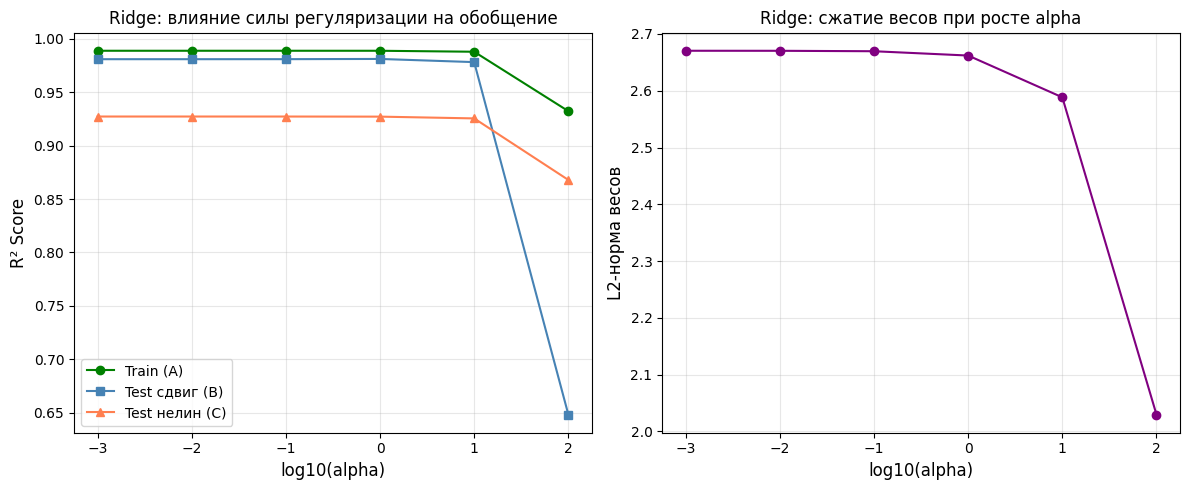


Результаты Ridge при разных alpha:

alpha        R² train   R² сдвиг   R² нелин  Норма весов
-------------------------------------------------------
0.0            0.9888     0.9809     0.9272        2.670
0.0            0.9888     0.9809     0.9272        2.670
0.1            0.9888     0.9809     0.9272        2.670
1.0            0.9888     0.9811     0.9271        2.662
10.0           0.9879     0.9782     0.9255        2.588
100.0          0.9323     0.6483     0.8679        2.030


In [40]:
# 6. АНАЛИЗ ВЕСОВ МОДЕЛЕЙ

print("\n" + "=" * 70)
print("СРАВНЕНИЕ ВЕСОВ МОДЕЛЕЙ")
print("=" * 70)

print(f"\n{'Модель':<22} {'w0':>8} {'w1':>8} {'w2':>8} {'w3':>8} {'w4':>8} {'Норма L2':>10}")
print("-" * 70)

for r in results:
    model = models[r["model"]]
    coefs = model.coef_
    norm = np.linalg.norm(coefs)
    print(f"{r['model']:<22} {coefs[0]:8.3f} {coefs[1]:8.3f} {coefs[2]:8.3f} {coefs[3]:8.3f} {coefs[4]:8.3f} {norm:10.3f}")

print(f"\nИстинные веса:          {true_weights[0]:8.3f} {true_weights[1]:8.3f} {true_weights[2]:8.3f} {true_weights[3]:8.3f} {true_weights[4]:8.3f}")

# ============================================================
# 7. ЭКСПЕРИМЕНТ: РАЗНАЯ СИЛА РЕГУЛЯРИЗАЦИИ
# ============================================================

print("\n" + "=" * 70)
print("ЭКСПЕРИМЕНТ: ВЛИЯНИЕ СИЛЫ РЕГУЛЯРИЗАЦИИ НА ОБОБЩЕНИЕ")
print("=" * 70)

alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
ridge_results = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)

    r2_train = r2_score(y_train, ridge.predict(X_train_scaled))
    r2_shifted = r2_score(y_test_shifted, ridge.predict(X_test_shifted_scaled))
    r2_nonlinear = r2_score(y_test_nonlinear, ridge.predict(X_test_nonlinear_scaled))

    ridge_results.append({
        "alpha": a,
        "r2_train": r2_train,
        "r2_shifted": r2_shifted,
        "r2_nonlinear": r2_nonlinear,
        "coef_norm": np.linalg.norm(ridge.coef_)
    })

# Визуализация влияния alpha
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(np.log10(alphas), [r["r2_train"] for r in ridge_results], 'o-', label='Train (A)', color='green')
plt.plot(np.log10(alphas), [r["r2_shifted"] for r in ridge_results], 's-', label='Test сдвиг (B)', color='steelblue')
plt.plot(np.log10(alphas), [r["r2_nonlinear"] for r in ridge_results], '^-', label='Test нелин (C)', color='coral')
plt.xlabel('log10(alpha)', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Ridge: влияние силы регуляризации на обобщение', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(np.log10(alphas), [r["coef_norm"] for r in ridge_results], 'o-', color='purple')
plt.xlabel('log10(alpha)', fontsize=12)
plt.ylabel('L2-норма весов', fontsize=12)
plt.title('Ridge: сжатие весов при росте alpha', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nРезультаты Ridge при разных alpha:")
print(f"\n{'alpha':<10} {'R² train':>10} {'R² сдвиг':>10} {'R² нелин':>10} {'Норма весов':>12}")
print("-" * 55)
for r in ridge_results:
    print(f"{r['alpha']:<10.1f} {r['r2_train']:10.4f} {r['r2_shifted']:10.4f} {r['r2_nonlinear']:10.4f} {r['coef_norm']:12.3f}")


Регуляризация помогает обобщению, но только при правильной силе.

Умеренная регуляризация (alpha ≈ 1.0) даёт небольшое улучшение на данных со сдвигом распределения.

Слишком слабая регуляризация (alpha < 1) почти не отличается от отсутствия регуляризации — полезного эффекта нет.

Слишком сильная регуляризация (alpha ≥ 10) начинает вредить, а при alpha = 100 качество на сдвинутых данных падает катастрофически — с R² 0.98 до 0.65.

Практический вывод: Всегда нужно подбирать силу регуляризации (например, через кросс-валидацию). Нельзя брать alpha «с потолка» — ни слишком маленькое, ни слишком большое. Оптимальное значение находится в узком диапазоне, и только оно даёт реальную пользу для обобщения.